In [1]:
# librerias
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix,negativity,state_fidelity,Operator,concurrence,entropy
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke


from qiskit_dynamics import Solver, Signal
from qiskit_dynamics.backend import parse_backend_hamiltonian_dict

from qiskit import pulse
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numpy as np
import random
import sympy as sym

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [2]:
# Llamar fake backend
backend = FakeSherbrooke()

#configuracion de backend
propiedades = backend.properties()
configuracion = backend.configuration()


Hz = 1e9
# Definicion de la frecuencia de los qubits en GHz
w7   = configuracion.hamiltonian.get("vars").get("wq7")
w8   = configuracion.hamiltonian.get("vars").get("wq8")
w9   = configuracion.hamiltonian.get("vars").get("wq9")
# anamornicidad de los qubits en GHz
delta7 = configuracion.hamiltonian.get("vars").get("delta7")
delta8 = configuracion.hamiltonian.get("vars").get("delta8")
delta9 = configuracion.hamiltonian.get("vars").get("delta9")
# acoples en GHz
J78 = configuracion.hamiltonian.get("vars").get("jq7q8")
J89 = configuracion.hamiltonian.get("vars").get("jq8q9")
# fuerza de control en GHz
r0   =  configuracion.hamiltonian.get("vars").get("omegad7")
r1   =  configuracion.hamiltonian.get("vars").get("omegad8")
r2   =  configuracion.hamiltonian.get("vars").get("omegad9")
# tiempo de gate en ns
dt = backend.dt*1e9


v7 = w7 /(2*np.pi)
v8 = w8 /(2*np.pi)
v9 = w9 /(2*np.pi)
# print(v7, v8, v9)
# print(delta7, delta8, delta9)
# print(J78, J89)
# print(r0, r1, r2)

# tiempo de relajación y decoherencia en segundos
T1_7 = propiedades.qubit_property(7,'T1')[0]  # tiempo de relajación
T2_7 = propiedades.qubit_property(7,'T2')[0]  # tiempo de decoherencia
T1_8 = propiedades.qubit_property(8,'T1')[0]  # tiempo de relajación
T2_8 = propiedades.qubit_property(8,'T2')[0]  # tiempo de decoherencia
T1_9 = propiedades.qubit_property(9,'T1')[0]  # tiempo de relajación    
T2_9 = propiedades.qubit_property(9,'T2')[0]  # tiempo de decoherencia  


v7 = w7/(2*np.pi)  # frecuencia en GHz
v8 = w8/(2*np.pi)  # frecuencia en GHz
v9 = w9/(2*np.pi)  # frecuencia en GHz  

rho_0 = DensityMatrix.from_label('00')

In [3]:
backend.qubit_properties(7).t1*1e9  #  ns

230522.19090722952

In [4]:
# Definir los operadores 
# diminsión del espacio de Hilbert de cada qubit
dim = 2
# operadores de creación, aniquilación y número
a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)
# operador numérico y de creación/aniquilación para cada qubit en el sistema de dos qubits
N0 =np.kron(ident, N)
N1 = np.kron(N, ident)

a0 = np.kron(ident, a)
a1 = np.kron(a, ident)

a0dag = np.kron(ident, adag)
a1dag = np.kron(adag, ident)


# Haniltoniano del sistema
H0 = (2*np.pi*v7*(a0dag @ a0) + delta7*(a0dag@a0dag@a0@a0)/2 + 
      2*np.pi*v8*(a1dag @ a1) + delta8*(a1dag@a1dag@a1@a1)/2 + 
      J78*(a0dag @ a1 + a0 @ a1dag))

# Hamiltoniano de control
Hc0 = r0*(a0 + a0dag)
Hc1 = r1*(a1 + a1dag)   

# Tiempos T1 y T2 en ns
T1_7 = T1_7*1e9
T2_7 = T2_7*1e9
T1_8 = T1_8*1e9
T2_8 = T2_8*1e9
# gammas de relajación y decoherencia
gamma1_7 = 1/T1_7
gamma2_7 = 1/T2_7 - 1/(2*T1_7)
gamma1_8 = 1/T1_8
gamma2_8 = 1/T2_8 - 1/(2*T1_8)

Z0 = full_ident - 2*N0
Z1 = full_ident - 2*N1

# estado inicial 
rho_0 = DensityMatrix.from_label('00')

sm1 = a0
sm2 = a1

sz1 = Z0
sz2 = Z1

collapse_operators = [np.sqrt(gamma1_7)*a0,
                      np.sqrt(gamma1_8)*a1,
                      np.sqrt(gamma2_7)*Z0,
                      np.sqrt(gamma2_8)*Z1]

In [5]:
solver = Solver(static_hamiltonian=H0,
                hamiltonian_operators=[Hc0, Hc1,Hc0],
                static_dissipators = collapse_operators,
                dissipator_channels= None,
                hamiltonian_channels=['d0', 'd1', 'u0'],
                channel_carrier_freqs= {"d0": v7, "d1": v8, "u0": v8 },
                dt=dt,
                array_library='jax'
                )

In [6]:
from qiskit import pulse

def esque_pul(params):
    t_0, t_1,A0, A1, A2  = params

    # Convertir a enteros por requerimiento del backend
    t_0 = int(t_0)
    t_1 = int(t_1)
  
    with pulse.build(name="pulso 3q") as kp:
        d0 = pulse.DriveChannel(0)
        d1 = pulse.DriveChannel(1)
        u0 = pulse.ControlChannel(0)
    

        # Primer pulso en d0 y d1
        pulse.play(pulse.Constant(duration=t_0, amp=A0), d0)
        pulse.play(pulse.Constant(duration=t_0, amp=A1), d1)   
        # Delay en canal u0
        pulse.delay(duration= t_0 + 1, channel=u0)
        # Segundo pulso en d1 y u0
        pulse.play(pulse.Constant(duration = t_1 , amp=A2), u0)
        # delay pulso d2 y u1        
    return kp

In [7]:
parametros_optimos_2 = [
        191.910934,
        797.242687,
        0.6824432988764655,
        0.8286644926788276,
        0.7868326972398657,
    ]

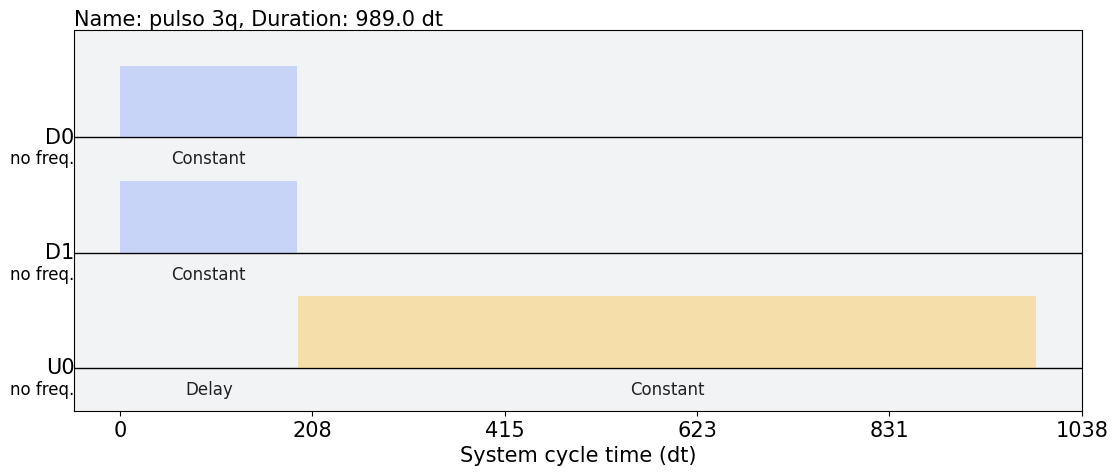

In [8]:
esque_pul(parametros_optimos_2).draw()

In [9]:
def objective_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        method="jax_odeint",
        atol=1e-7,
        rtol=1e-8
    )
    yf = sol.y[-1]
    cost = (negativity(yf,[0]) -  0.5)**2 + (negativity(yf,[1]) -  0.5)**2 
    return cost
  

In [10]:
objective_bell_lindblab(parametros_optimos_2)

np.float64(0.0008085040082453564)

In [11]:
def evol_bell_lindblab(x):
    signal = esque_pul(x)
    tiempo_t = signal.duration  # duración total del pulso en pasos de dt
    sol = solver.solve(
        t_span=[0, tiempo_t*dt],
        y0=rho_0,
        signals=signal,
        # method="jax_odeint",
        atol=1e-9,
        rtol=1e-9
    )
    
    return sol

In [12]:
evolucion = evol_bell_lindblab(parametros_optimos_2)

In [29]:
negati   = []
tiempo = []
for i in range(len(evolucion.t)):
    negati.append(negativity(evolucion.y[i],[1]))
    tiempo.append(evolucion.t[i])


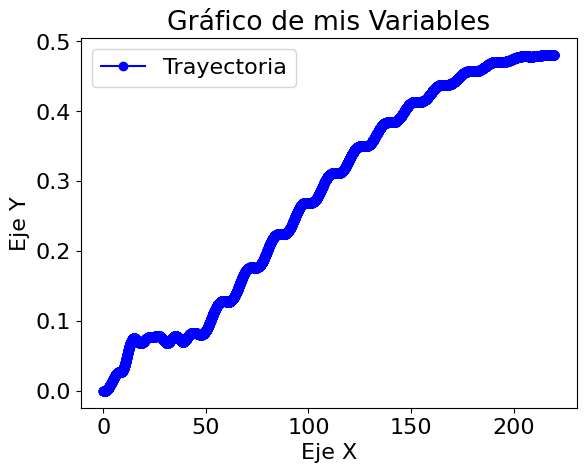

In [30]:
# Crear el gráfico de líneas con puntos marcados
plt.plot(tiempo, negati, marker='o', linestyle='-', color='b', label='Trayectoria')

# Añadir títulos y etiquetas
plt.title("Gráfico de mis Variables")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()

# Mostrar el resultado
plt.show()

In [13]:
xi_data = []
yi_data = []
zi_data = []
for estado in evolucion.y:
    estado_norm = estado 
    rho = DensityMatrix(estado_norm)
    rho_red = partial_trace(rho, [1])
    xi = rho_red.expectation_value(Operator.from_label('X')).real
    yi = rho_red.expectation_value(Operator.from_label('Y')).real
    zi = rho_red.expectation_value(Operator.from_label('Z')).real
    xi_data.append(xi)
    yi_data.append(yi)
    zi_data.append(zi)

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PC\AppData\Local\Temp\ipykernel_15468\2263855718.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(evolucion.t, zi_data, label = '$ N^{-1}\sum_i \\langle Z_i \\rangle$')


Text(0.5, 1.0, 'Mean Bloch vector vs. $t$')

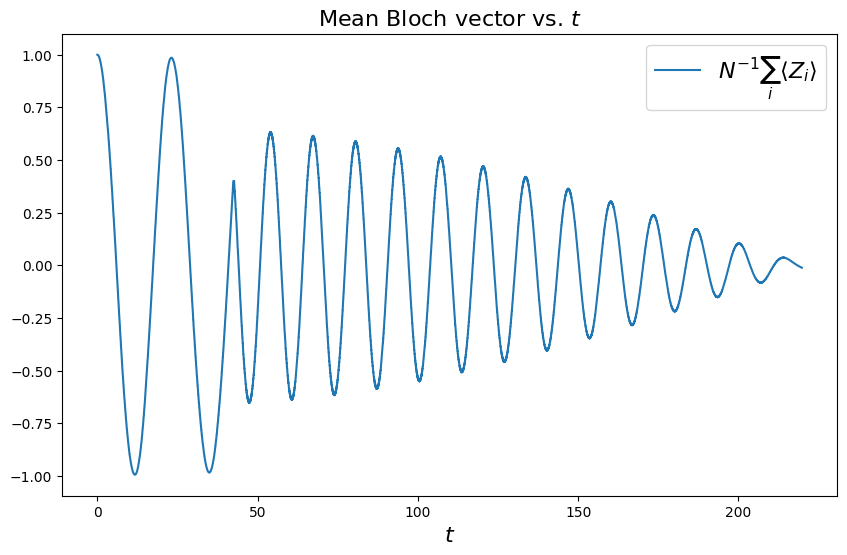

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

fontsize = 16

_, ax = plt.subplots(figsize = (10, 6))
plt.rcParams.update({'font.size': fontsize})
# plt.plot(evolucion.t, xi_data, label = '$ N^{-1}\sum_i \\langle X_i \\rangle$')
# plt.plot(evolucion.t, yi_data, label = '$ N^{-1}\sum_i \\langle Y_i \\rangle$')
plt.plot(evolucion.t, zi_data, label = '$ N^{-1}\sum_i \\langle Z_i \\rangle$')
plt.legend(fontsize = fontsize)
ax.set_xlabel('$t$', fontsize = fontsize)
ax.set_title('Mean Bloch vector vs. $t$', fontsize = fontsize)

In [15]:
np.trace(evolucion.y[-1].data)

np.complex128(0.9999999999999989+0j)

In [16]:
dim        = 2
# operadores de creación, aniquilación y número 
a          = np.diag(np.sqrt(np.arange(1,dim)),1)
adag       = np.diag(np.sqrt(np.arange(1,dim)),-1)
N          = np.diag(np.arange(dim))

ident      = np.eye(dim, dtype=complex)
full_indet = np.eye(dim**3, dtype=complex)
# operador número y creación/aniquilación para cada qubit en el sistema de dos qubits
N0         = np.kron(ident,np.kron(ident,N))
N1         = np.kron(ident,np.kron(N,ident))
N2         = np.kron(np.kron(N,ident),ident)

# operador de creación 
a0         = np.kron(ident,np.kron(ident,a))
a1         = np.kron(ident,np.kron(a,ident))
a2         = np.kron(np.kron(a,ident),ident)
# operador de aniquilación
a0dag      = np.kron(ident,np.kron(ident,adag))
a1dag      = np.kron(ident,np.kron(adag,ident))
a2dag      = np.kron(np.kron(adag,ident),ident)

# Hamiltoniano del sistema
# Haniltoniano del sistema
# Haniltoniano del sistema
static_ham = 2*np.pi*v7 * N0  + 2*np.pi*v8 * N1  + 2*np.pi*v9* N2   + J78*(a0dag @ a1 +  a0 @ a1dag) + J89*(a1dag @ a2 +  a1 @ a2dag)


In [17]:
GHZ = Statevector([1,0,0,0,0,0,0,1]/np.sqrt(2))
DensityMatrix(GHZ).draw("latex")
SAB = partial_trace(DensityMatrix(GHZ),[2]) 
SAB.draw("latex")
SAC = partial_trace(DensityMatrix(GHZ),[1])
SAC.draw("latex")
SA  = partial_trace(DensityMatrix(GHZ),[1,2])
SA.draw("latex")

<IPython.core.display.Latex object>

In [18]:
C_A_BC = np.sqrt(2*(1-np.trace(SA.data @ SA.data)))
C_A_BC

np.complex128(1.0000000000000002+0j)

In [19]:
import numpy as np
from qiskit.quantum_info import random_statevector, DensityMatrix

def random_mixed_state(dim, n_states=3):
    probs = np.random.rand(n_states)
    probs /= np.sum(probs)

    rho = 0
    for p in probs:
        psi = random_statevector(dim)
        rho += p * DensityMatrix(psi).data

    return DensityMatrix(rho)

rho = random_mixed_state(8, n_states=3)

In [20]:
np.trace(rho.data @ rho.data)
rho.purity()

np.complex128(0.44929494143040116+2.5719067721186147e-18j)

In [28]:
negativity(SAC,[0])

np.float64(-1.1102230246251565e-16)

In [34]:
rho_ABC = DensityMatrix(GHZ)
min(negativity(rho_ABC,[2]),negativity(rho_ABC,[1]))

np.float64(0.4999999999999998)

In [38]:
W = Statevector([0,1,1,0,1,0,0,0]/np.sqrt(3))
W.draw("latex")

<IPython.core.display.Latex object>

In [44]:
rho_w = DensityMatrix(W)
min(negativity(rho_w,[0]),negativity(rho_w,[1]),negativity(rho_w,[2]))

np.float64(0.471404520791032)

In [64]:
# Matriz densidad
def random_denseity_matrix(dim):
    A = np.random.randn(dim,dim) + 1j*np.random.randn(dim,dim)
    rho = A@A.conj().T
    rho = rho / np.trace(rho)
    return DensityMatrix(rho)

# N_GME

def N_GME(rho):
    
    N_A = negativity(rho, [0])
    N_B = negativity(rho, [1])
    N_C = negativity(rho, [2])
    
    return min(N_A, N_B, N_C)
    



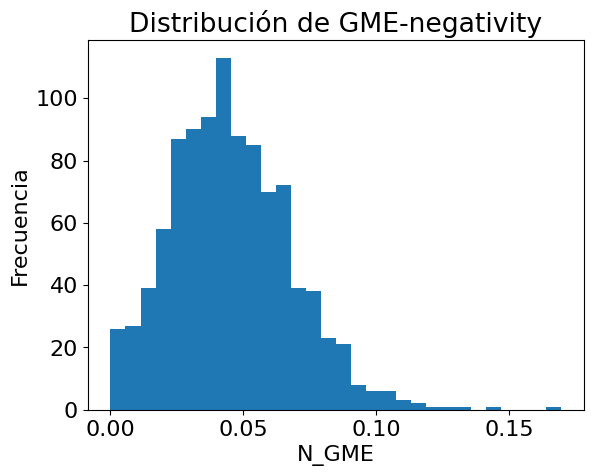

In [67]:
# -----------------------------
# Simulación
# -----------------------------
num_states = 1000  # puedes aumentar

gme_values = []

for _ in range(num_states):
    rho = random_denseity_matrix(8)  # 3 qubits → dim=8
    gme = N_GME(rho)
    gme_values.append(gme)

# -----------------------------
# Gráfica
# -----------------------------
plt.figure()
plt.hist(gme_values, bins=30)
plt.xlabel("N_GME")
plt.ylabel("Frecuencia")
plt.title("Distribución de GME-negativity")
plt.show()